# Question 6 — Derivative of Gaussian
- (a) Derive ∂G/∂x and ∂G/∂y analytically
- (b) Compute normalized 5×5 DoG kernels (σ=2)
- (c) Visualize 51×51 DoG kernel as 3D surface
- (d) Apply to get image gradients
- (e) Compare with cv.Sobel()

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
%matplotlib inline

def norm_disp(img):
    """Normalize to [0,255] uint8 for display."""
    img = img - img.min()
    if img.max() > 0: img = img / img.max() * 255
    return img.astype(np.uint8)

## (a) Derivation

$$G(x,y) = \frac{1}{2\pi\sigma^2}\exp\!\left(-\frac{x^2+y^2}{2\sigma^2}\right)$$

Applying the chain rule:
$$\frac{\partial G}{\partial x} = \frac{1}{2\pi\sigma^2}\cdot e^{-\frac{x^2+y^2}{2\sigma^2}}\cdot\left(-\frac{x}{\sigma^2}\right) = -\frac{x}{\sigma^2}\,G(x,y)$$

By symmetry (y appears identically to x):
$$\frac{\partial G}{\partial y} = -\frac{y}{\sigma^2}\,G(x,y)$$

These kernels are antisymmetric — negative on one side, positive on the other — which is what makes them detect edges.

In [2]:
# (b) Compute DoG kernels
def dog_kernels(size, sigma):
    ax = np.arange(-(size // 2), size // 2 + 1)
    X, Y = np.meshgrid(ax, ax)
    G  = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    Gx = -(X / sigma**2) * G
    Gy = -(Y / sigma**2) * G
    # Normalize by sum of absolute values
    Gx /= np.sum(np.abs(Gx))
    Gy /= np.sum(np.abs(Gy))
    return Gx, Gy

sigma = 2
Gx, Gy = dog_kernels(5, sigma)
print('DoG kernel x-direction:'); print(np.array2string(Gx, precision=4, suppress_small=True))
print('\nDoG kernel y-direction:'); print(np.array2string(Gy, precision=4, suppress_small=True))
print(f'\nSum Gx (should be ~0): {Gx.sum():.2e}')
print(f'Sum Gy (should be ~0): {Gy.sum():.2e}')

DoG kernel x-direction:
[[ 0.0441  0.0321 -0.     -0.0321 -0.0441]
 [ 0.0642  0.0467 -0.     -0.0467 -0.0642]
 [ 0.0728  0.0529 -0.     -0.0529 -0.0728]
 [ 0.0642  0.0467 -0.     -0.0467 -0.0642]
 [ 0.0441  0.0321 -0.     -0.0321 -0.0441]]

DoG kernel y-direction:
[[ 0.0441  0.0642  0.0728  0.0642  0.0441]
 [ 0.0321  0.0467  0.0529  0.0467  0.0321]
 [-0.     -0.     -0.     -0.     -0.    ]
 [-0.0321 -0.0467 -0.0529 -0.0467 -0.0321]
 [-0.0441 -0.0642 -0.0728 -0.0642 -0.0441]]

Sum Gx (should be ~0): 0.00e+00
Sum Gy (should be ~0): 3.47e-17


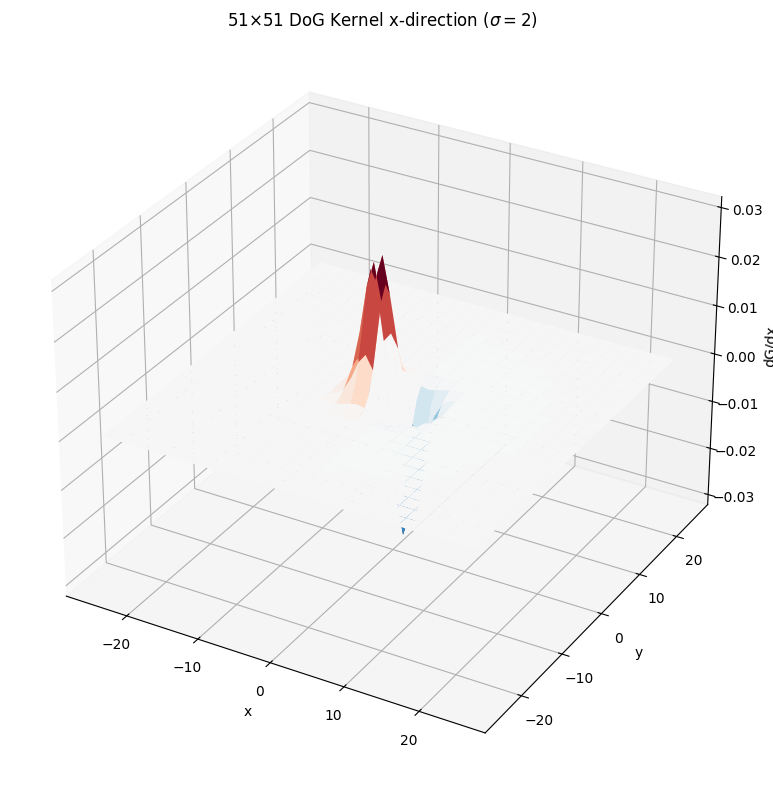

In [3]:
# (c) 3D surface — 51×51 x-direction kernel
Gx51, _ = dog_kernels(51, sigma)
ax_vals  = np.arange(-(51 // 2), 51 // 2 + 1)
X51, Y51 = np.meshgrid(ax_vals, ax_vals)

fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')
ax.plot_surface(X51, Y51, Gx51, cmap=cm.RdBu_r, linewidth=0, antialiased=True)
ax.set_title(rf'51×51 DoG Kernel x-direction ($\sigma={sigma}$)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('dG/dx')
plt.tight_layout()
plt.savefig('outputs/q6c_dog_surface.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Load runway image
img = cv.imread('images/runway.png', cv.IMREAD_GRAYSCALE)
assert img is not None

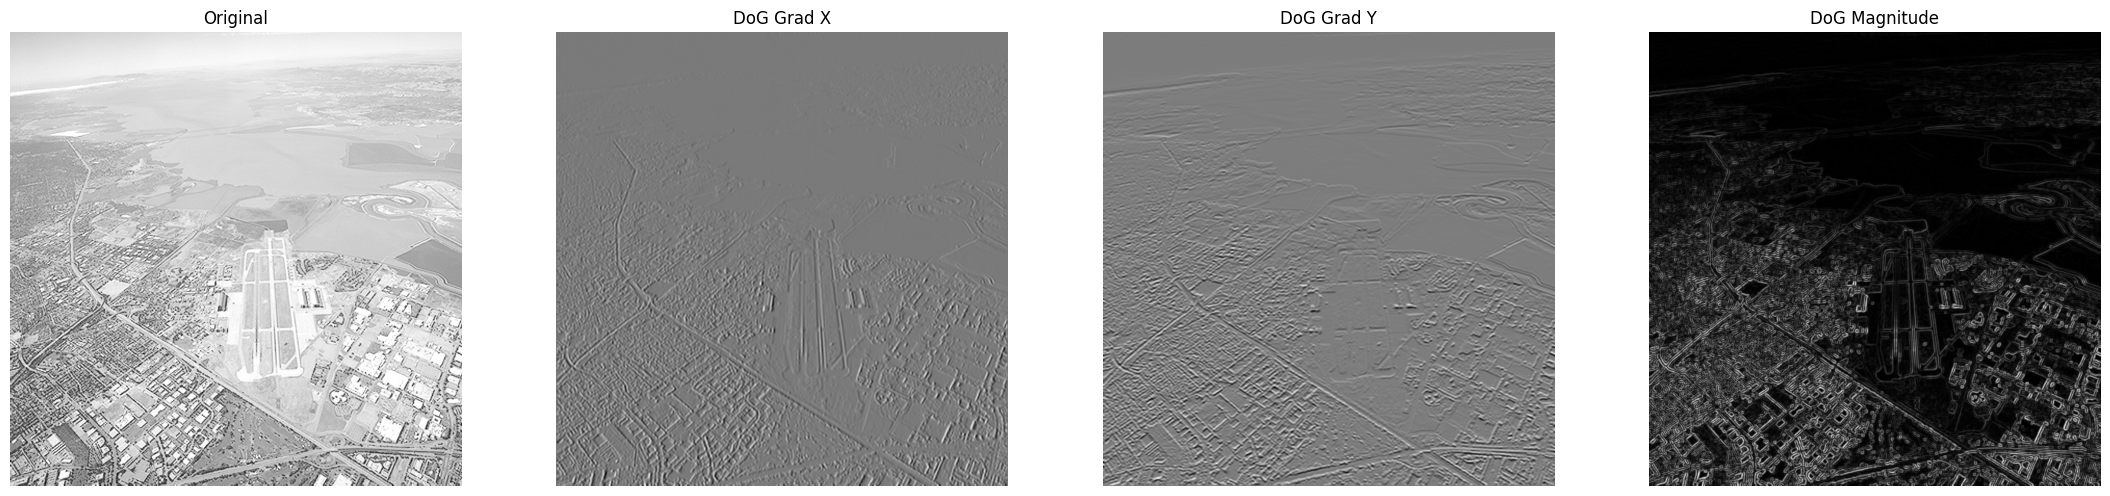

In [5]:
# (d) Apply DoG kernels
grad_x = cv.filter2D(img, cv.CV_64F, Gx)
grad_y = cv.filter2D(img, cv.CV_64F, Gy)
mag    = np.sqrt(grad_x**2 + grad_y**2)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, data, title in zip(axes,
    [img, grad_x, grad_y, mag],
    ['Original', 'DoG Grad X', 'DoG Grad Y', 'DoG Magnitude']):
    ax.imshow(norm_disp(data), cmap='gray')
    ax.set_title(title); ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/q6d_dog_gradients.png', dpi=150, bbox_inches='tight')
plt.show()

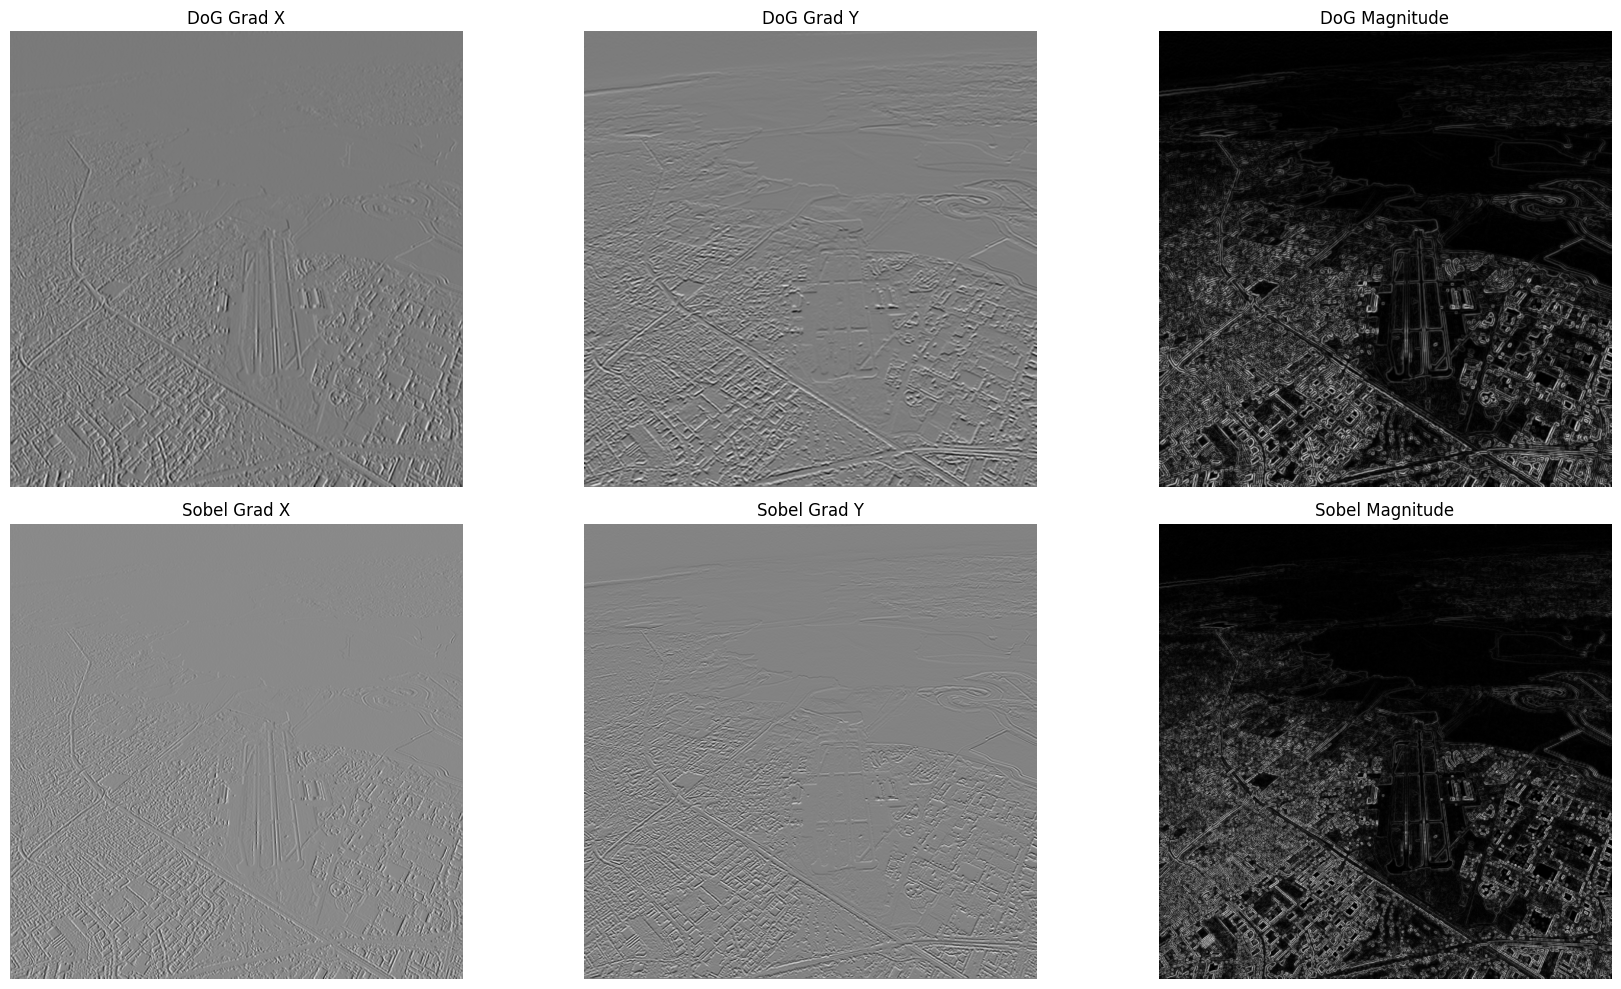

DoG vs Sobel differences:
1. Smoothing : DoG has built-in Gaussian smoothing; Sobel has minimal smoothing
2. Kernel    : Sobel is fixed 3×3; DoG size is controlled by σ
3. Edges     : Sobel gives sharper/thinner edges; DoG gives smoother/wider edges
4. Noise     : Sobel is more sensitive to noise; DoG suppresses it better


In [6]:
# (e) Compare with Sobel
sobel_x = cv.Sobel(img, cv.CV_64F, 1, 0, ksize=3)
sobel_y = cv.Sobel(img, cv.CV_64F, 0, 1, ksize=3)
sobel_m = np.sqrt(sobel_x**2 + sobel_y**2)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, data, title in zip(axes[0],
    [grad_x, grad_y, mag],
    ['DoG Grad X', 'DoG Grad Y', 'DoG Magnitude']):
    ax.imshow(norm_disp(data), cmap='gray'); ax.set_title(title); ax.axis('off')
for ax, data, title in zip(axes[1],
    [sobel_x, sobel_y, sobel_m],
    ['Sobel Grad X', 'Sobel Grad Y', 'Sobel Magnitude']):
    ax.imshow(norm_disp(data), cmap='gray'); ax.set_title(title); ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/q6e_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('DoG vs Sobel differences:')
print('1. Smoothing : DoG has built-in Gaussian smoothing; Sobel has minimal smoothing')
print('2. Kernel    : Sobel is fixed 3×3; DoG size is controlled by σ')
print('3. Edges     : Sobel gives sharper/thinner edges; DoG gives smoother/wider edges')
print('4. Noise     : Sobel is more sensitive to noise; DoG suppresses it better')